# 05b — Archives (cellules retirées du notebook principal)

**Date : 7 juillet 2026 — retirées du `05b_Portefeuille_Membre_MathSpec.ipynb` (état source : commit `a5b14d4`).**

⚠️ **Ce notebook n'est PAS exécutable seul** : les cellules dépendent de l'état du 05b
(`df`, `wf_ret`, `cal`, `select_topK`, …). Les **outputs sont figés** — ce sont ceux du dernier
run validé du 05b.

**Pourquoi ces cellules ont été retirées.** Le calcul du rendement du portefeuille se fait
désormais **uniquement en parts** (méthode du maître de recherche : `nbr^k` constants entre
coupes, NAV continue — §6 du 05b, spécifiée dans `NOTE_NAV_PORTEFEUILLE_EN_PARTS.md`).
L'ancienne écriture « Σ w·cumprod par bloc + concaténation » est **mathématiquement équivalente**
(prouvé : max |Δ rendement quotidien| ~ 1e-16, voir la cellule « preuve » ci-dessous et ses
outputs), mais on ne garde qu'une seule écriture. Sont archivés ici :
1. l'**ancien §6** — `run_strategy` (modes `fixed`/`drift`) + la démonstration du bug des poids
   figés trouvé par Alice ($t$ 1,14 → 0,94) ;
2. les anciens markdown du **§10** d'origine ;
3. l'**ancien moteur semestriel** `run_strategy_6m` (§9) ;
4. la **preuve d'équivalence** ancien-moteur vs parts (tableau par paires identiques) ;
5. l'ancien **§7** top-4 (fusionné dans le §6 du 05b le 8 juillet 2026).

## 1. L'ancien §6 : combinaison Σ w·cumprod (figé vs dérive)

## 6. La combinaison : buy-and-hold (commune aux deux critères)
« Copier et **tenir** » laisse les poids **dériver** avec la performance ; les figer reviendrait à
rebalancer chaque jour (faux) :
$$\mathrm{NAV}_k(t)=\prod_{s\le t}(1+r_{m_k}(s)),\quad N(t)=\sum_k w_k\,\mathrm{NAV}_k(t),\quad
r_{\text{strat}}(t)=\frac{N(t)}{N(t-1)}-1.$$

In [27]:
def run_strategy(K, mode, years=range(2015, 2026), combine="drift", critere="ir"):
    parts = []
    for Y in years:
        sel = select_topK(Y, K, critere=critere)
        if not sel:
            continue
        if mode == "equal":
            w = np.ones(len(sel)) / len(sel)
        else:                                             # "score" = poids proportionnels au score du critère
            sc = np.array([s for s, _ in sel])
            w = sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)
        idx = cal[cal.year == (Y + 1)]
        if len(idx) == 0:
            continue
        R = pd.DataFrame({bid: wf_ret[bid].reindex(idx).fillna(0.0) for _, bid in sel})
        if combine == "fixed":                       # ANCIEN : poids figés = rebalancement quotidien
            parts.append((R * w).sum(axis=1))
        else:                                         # DRIFT : poids qui dérivent (buy-and-hold)
            navk = (1 + R).cumprod()
            navc = (navk * w).sum(axis=1)
            ry = navc / navc.shift(1) - 1
            ry.iloc[0] = navc.iloc[0] - 1
            parts.append(ry)
    return pd.concat(parts).sort_index()

def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: ((1 + r[r.index.year == y]).prod() - 1) - ((1 + b[r.index.year == y]).prod() - 1)
                      for y in sorted(set(r.index.year))})

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

def _ligne(r):
    e = eval_yearly(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_moyen"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

# les 4 séries de sélection IR (calculées une fois)
r_fix_eq = run_strategy(4, "equal", combine="fixed", critere="ir")
r_dr_eq  = run_strategy(4, "equal", combine="drift", critere="ir")
r_fix_ir = run_strategy(4, "score", combine="fixed", critere="ir")
r_dr_ir  = run_strategy(4, "score", combine="drift", critere="ir")
print("séries stratégie prêtes")

séries stratégie prêtes


In [28]:
# La combinaison figée SURESTIME : top-4 sélection IR, figé vs dérive
pd.DataFrame({
    "top-4 sél IR (1/K) — figé":   eval_yearly(r_fix_eq),
    "top-4 sél IR (1/K) — dérive": eval_yearly(r_dr_eq),
}).T[["exces_moyen", "t", "gagnantes"]].round(3)

,exces_moyen,t,gagnantes
top-4 sél IR (1/K) — figé,0.036491,1.141628,7/11
top-4 sél IR (1/K) — dérive,0.031021,0.943191,7/11


**Lecture.** Les poids figés **surestiment** (rebalancement fantôme) : le $t$ passe de $1{,}14$
(figé) à $0{,}94$ (dérive). On garde la dérive partout.

## 2. Les markdown d'origine du §10 « écrit en parts » (devenu le §6 du 05b)

## 10. La même combinaison, écrite en parts (formalisation du maître de recherche)
Chaque membre $k$ = un **fonds** dont le prix de part est $\mathrm{NAV}^k(t)=\prod_{s\le t}(1+r_k(s))$,
calculé **une fois sur tout le calendrier** (plate hors fenêtre active $=$ cash). Le portefeuille ne
suit qu'une chose : ses **nombres de parts** $\mathrm{nbr}^k$, constants entre deux rebalancements.
- **Au rebalancement** $t_j^R$ (fin de journée) : richesse disponible
  $\mathrm{NAV}^{\mathrm{avl}} = \sum_k \mathrm{nbr}^k_{\text{anciens}}\,\mathrm{NAV}^k(t_j^R)$, puis
  $\mathrm{nbr}^k = w_j^k\,\mathrm{NAV}^{\mathrm{avl}} / \mathrm{NAV}^k(t_j^R)$.
- **Entre deux coupes** : $\mathrm{NAV}(t)=\sum_k \mathrm{nbr}^k\,\mathrm{NAV}^k(t)$, série **continue**
  (base 100), et $r_{\text{strat}}(t)=\mathrm{NAV}(t)/\mathrm{NAV}(t-1)-1$.
- **Autofinancement** : $\sum_k \mathrm{nbr}^k_{\text{nouveaux}}\,\mathrm{NAV}^k(t_j^R)=\mathrm{NAV}^{\mathrm{avl}}$
  $\Rightarrow$ aucun saut à la coupe.

Mêmes sélections, mêmes poids initiaux, même buy-and-hold que §6–§9 — on **prouve** ci-dessous que
les rendements sont identiques.

**Lecture.**
- L'écriture en parts et la combinaison « dérive » des §6–§9 sont **le même calcul** :
  max $|\Delta| \sim 10^{-16}$ (bruit machine) sur toutes les configurations $\Rightarrow$ **tous les
  chiffres et conclusions des §6–§9 restent valides tels quels**.
- L'apport du formalisme : la **NAV continue** (base 100) est l'objet naturel — chaque coupe est
  autofinancée (on compte avec les anciennes parts, on redéploie aux nouveaux poids), et **tout**
  rendement (jour, semestre, année, fenêtre $D_H$ quelconque) est un ratio de deux points de cette
  courbe.
- La moyenne à poids **figés** du §6 reste, dans ce langage, l'erreur « parts non constantes » :
  elle revend les gagnants chaque soir sans le dire.

## 3. L'ancien moteur semestriel du §9 (`run_strategy_6m`, cellule complète d'origine)

In [35]:
# --- Moteur SEMESTRIEL : coupe 30/06 & 31/12, on tient le semestre suivant ---
def classement_a_date(d, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """classement_a_fin, mais à une DATE de coupe quelconque (point-in-time strict <= d)."""
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        n_trades = int((wf_traded[bid] <= d).sum()); n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252); t = score * np.sqrt(n_days / 252)
        else:
            ab = alpha_beta(rr); score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, score=score))
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=["bioguide_id", "score"]))

cuts = [pd.Timestamp(y, m, dd) for y in range(2015, 2026) for (m, dd) in [(6, 30), (12, 31)]]
next_bound = lambda d: pd.Timestamp(d.year, 12, 31) if d.month == 6 else pd.Timestamp(d.year + 1, 6, 30)
clsmt6_ir = {d: classement_a_date(d, critere="ir")        for d in cuts}
clsmt6_ap = {d: classement_a_date(d, critere="appraisal") for d in cuts}

def run_strategy_6m(K, mode="equal", critere="ir"):
    cache = clsmt6_ir if critere == "ir" else clsmt6_ap
    parts = []
    for d in cuts:
        c = cache[d]
        if len(c) == 0:
            continue
        sel = list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
        if mode == "equal":
            w = np.ones(len(sel)) / len(sel)
        else:
            sc = np.array([s for s, _ in sel]); w = sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)
        idx = cal[(cal > d) & (cal <= next_bound(d))]
        if len(idx) == 0:
            continue
        R = pd.DataFrame({bid: wf_ret[bid].reindex(idx).fillna(0.0) for _, bid in sel})
        navk = (1 + R).cumprod(); navc = (navk * w).sum(axis=1)
        ry = navc / navc.shift(1) - 1; ry.iloc[0] = navc.iloc[0] - 1
        parts.append(ry)
    return pd.concat(parts).sort_index()

def eval_sem(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    sem = r.index.year.values * 2 + (r.index.month.values > 6).astype(int)
    e = pd.Series({s: ((1 + r[sem == s]).prod() - 1) - ((1 + b[sem == s]).prod() - 1) for s in sorted(set(sem))})
    n = len(e); ir = e.mean() / e.std(ddof=1)
    return dict(exces_an=2 * e.mean(), t=ir * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}", n=n)

def _ligne6(r):
    e = eval_sem(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_an"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

r_6m_ir = run_strategy_6m(4, "equal", "ir")
r_6m_ap = run_strategy_6m(4, "equal", "appraisal")
print(f"moteur 6 mois prêt | {len(cuts)} coupes | n semestres : IR={eval_sem(r_6m_ir)['n']}, appr={eval_sem(r_6m_ap)['n']}")

moteur 6 mois prêt | 22 coupes | n semestres : IR=22, appr=22


## 4. La preuve d'équivalence : ancien moteur vs NAV en parts (asserts + tableau par paires)

In [40]:
# PREUVE : la NAV en parts = une autre ÉCRITURE du même calcul -> les lignes du tableau, par paires IDENTIQUES
paires = {
    "top-4 sél IR (1/K) — annuel":       (r_dr_eq, strategie_en_parts(4, "equal", "ir"),              _ligne),
    "top-4 sél appraisal — annuel":      (r_ap_eq, strategie_en_parts(4, "equal", "appraisal"),       _ligne),
    "top-4 sél IR — 6 mois":             (r_6m_ir, strategie_en_parts(4, "equal", "ir", "6m"),        _ligne6),
    "top-4 sél appraisal — 6 mois":      (r_6m_ap, strategie_en_parts(4, "equal", "appraisal", "6m"), _ligne6),
}
rows = {}
for nom_s, (ancien, det, ligne_fn) in paires.items():
    assert ancien.index.equals(det["r"].index)
    assert np.allclose(ancien.values, det["r"].values, rtol=0, atol=1e-10)   # identiques au bruit machine près
    rows[f"{nom_s} — moteur §6/§9"] = ligne_fn(ancien)
    rows[f"{nom_s} — en parts §10"] = ligne_fn(det["r"])
assert np.allclose(r_dr_ir.values, strategie_en_parts(4, "score", "ir")["r"].values, rtol=0, atol=1e-10)  # idem ∝score
det4 = strategie_en_parts(4, "equal", "ir")                # réutilisé par les 2 cellules suivantes
assert np.allclose(det4["nav"], 100 * (1 + det4["r"]).cumprod(), rtol=0, atol=1e-9)
print("asserts passés (max|Δ rendement quotidien| ~ 1e-16) : chaque paire de lignes est identique")
pd.DataFrame(rows).T.round(3)

asserts passés (max|Δ rendement quotidien| ~ 1e-16) : chaque paire de lignes est identique


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
top-4 sél IR (1/K) — annuel — moteur §6/§9,0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
top-4 sél IR (1/K) — annuel — en parts §10,0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
top-4 sél appraisal — annuel — moteur §6/§9,-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
top-4 sél appraisal — annuel — en parts §10,-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
top-4 sél IR — 6 mois — moteur §6/§9,0.00432,0.137703,12/22,1.237727,-0.024558,-0.638371
top-4 sél IR — 6 mois — en parts §10,0.00432,0.137703,12/22,1.237727,-0.024558,-0.638371
top-4 sél appraisal — 6 mois — moteur §6/§9,-0.050248,-2.000941,8/22,1.047842,-0.050651,-1.481435
top-4 sél appraisal — 6 mois — en parts §10,-0.050248,-2.000941,8/22,1.047842,-0.050651,-1.481435


## 5. L'ancien §7 « Top-4 : sélection IR vs sélection appraisal » (retiré le 8 juillet 2026, source `e24fcd6`)
Fusionné dans le §6 du 05b : la table IR ∥ appraisal y est conservée (6.3) ; la figure NAV
ci-dessous était redondante avec la figure du §6 (mêmes séries `r_dr_eq`/`r_ap_eq`, mêmes chiffres).

## 7. Top-4 : sélection IR vs sélection appraisal
On copie chaque année les 4 meilleurs — une fois classés par **IR**, une fois par **appraisal** —
et on compare (combinaison en parts, 2016-2026).

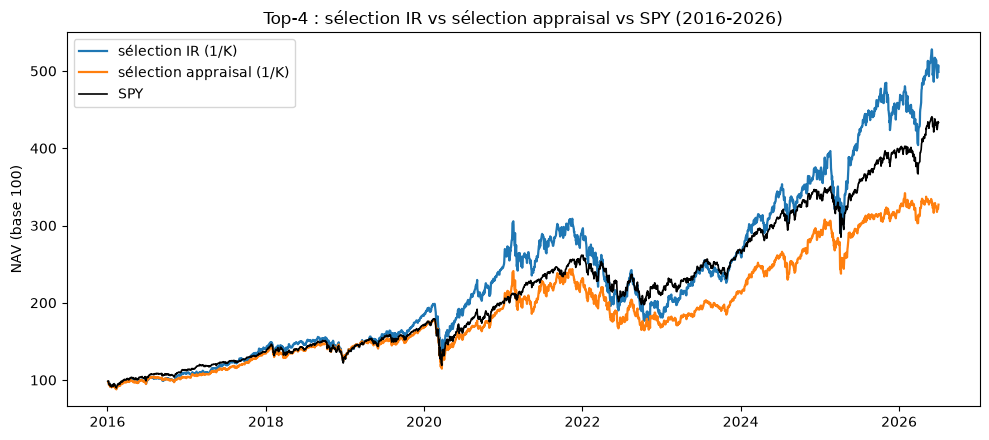

In [32]:
# FIGURE : NAV sélection IR vs sélection appraisal vs SPY (base 100)
nav_ir = 100 * (1 + r_dr_eq).cumprod()
nav_ap = 100 * (1 + r_ap_eq).cumprod()
idx = nav_ir.index.union(nav_ap.index)
nav_sp = 100 * (1 + r_spy.reindex(idx).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_ir, label="sélection IR (1/K)", lw=1.6)
plt.plot(nav_ap, label="sélection appraisal (1/K)", lw=1.6)
plt.plot(nav_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)"); plt.title("Top-4 : sélection IR vs sélection appraisal vs SPY (2016-2026)")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Le zoom « les parts en action » (retiré du §6.3 le 8 juillet 2026, source `01ce2b4`)
Tableau du rebalancement de la coupe fin-2020 (top-4 sél IR) : parts avant/après, autofinancement chiffré.

In [29]:
# LES PARTS EN ACTION : la coupe fin 2020 -> tenue 2021 (top-4 sél IR)
j_av, j_ap = [(a, b) for a, b in zip(det4["journal"], det4["journal"][1:])
              if b["rebal"].year == 2020][0]
tR = j_ap["rebal"]; nom = lambda b: df.loc[df.bioguide_id == b, "name"].iloc[0]
tous = j_av["nbr"].index.union(j_ap["nbr"].index)
zoom = pd.DataFrame({
    "parts avant (tenue 2020)": j_av["nbr"].reindex(tous).fillna(0.0),
    "parts après (tenue 2021)": j_ap["nbr"].reindex(tous).fillna(0.0),
    "prix de part NAV^k(tR)":   NAVK.loc[tR, tous],
})
zoom["valeur avant"] = zoom["parts avant (tenue 2020)"] * zoom["prix de part NAV^k(tR)"]
zoom["valeur après"] = zoom["parts après (tenue 2021)"] * zoom["prix de part NAV^k(tR)"]
zoom.index = [nom(b) for b in tous]
assert abs(zoom["valeur avant"].sum() - zoom["valeur après"].sum()) < 1e-9 * j_ap["W_avant"]
print(f"les parts en action (top-4 sél IR) — coupe du {tR.date()} : on compte {j_ap['W_avant']:.2f} avec les ANCIENNES parts, "
      f"on redéploie {zoom['valeur après'].sum():.2f} aux nouveaux poids — autofinancement, la NAV ne saute pas")
zoom.round(3)

les parts en action (top-4 sél IR) — coupe du 2020-12-31 : on compte 245.93 avec les ANCIENNES parts, on redéploie 245.93 aux nouveaux poids — autofinancement, la NAV ne saute pas


,parts avant (tenue 2020),parts après (tenue 2021),prix de part NAV^k(tR),valeur avant,valeur après
Donald Sternoff Beyer,0.000,40.087,1.534,0.000,61.483
Barbara J. Comstock,20.778,18.031,3.410,70.849,61.483
Gilbert Cisneros,0.000,32.957,1.866,0.000,61.483
Dwight Evans,21.984,0.000,2.512,55.219,0.000
Denny Heck,24.334,0.000,2.353,57.265,0.000
Thomas Suozzi,28.631,0.000,2.186,62.598,0.000
MARK R WARNER,0.000,7.749,7.935,0.000,61.483
